In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

# Set your path
data_dir = Path(r"D:\Study\6th Semester\Labs\ANN LAB\sports")

# Get all subfolder names (these are your labels)
categories = [f.name for f in data_dir.iterdir() if f.is_dir()]

print(f"Found {len(categories)} sports categories.")
print(f"Categories: {categories[:10]}...") # Shows first 10

Found 22 sports categories.
Categories: ['badminton', 'baseball', 'basketball', 'boxing', 'chess', 'cricket', 'fencing', 'football', 'formula1', 'gymnastics']...


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image size and batch size
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# 1. Training Generator with Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalize pixel values
    rotation_range=20,         # Randomly rotate images
    width_shift_range=0.2,     # Shift horizontally
    height_shift_range=0.2,    # Shift vertically
    shear_range=0.2,           # Shear transformations
    zoom_range=0.2,            # Random zoom
    horizontal_flip=True,      # Flip images
    fill_mode='nearest',
    validation_split=0.2       # Reserve 20% for validation
)

# 2. Load Training Data
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',         # Use the 80% portion
    shuffle=True
)

# 3. Load Validation Data (No augmentation, only rescaling)
validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',       # Use the 20% portion
    shuffle=False
)

print(f"Classes found: {train_generator.class_indices}")

Found 12505 images belonging to 22 classes.
Found 3117 images belonging to 22 classes.
Classes found: {'badminton': 0, 'baseball': 1, 'basketball': 2, 'boxing': 3, 'chess': 4, 'cricket': 5, 'fencing': 6, 'football': 7, 'formula1': 8, 'gymnastics': 9, 'hockey': 10, 'ice_hockey': 11, 'kabaddi': 12, 'motogp': 13, 'shooting': 14, 'swimming': 15, 'table_tennis': 16, 'tennis': 17, 'volleyball': 18, 'weight_lifting': 19, 'wrestling': 20, 'wwe': 21}


In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# 1. Load the pre-trained MobileNetV2 base
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Keep the base frozen for now

# 2. Build the model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),  # Helps prevent overfitting
    layers.Dense(train_generator.num_classes, activation='softmax') # Dynamic class count
])

# 3. FIX: Compile with the correct loss name 'categorical_crossentropy'
model.compile(
    optimizer='adam', 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 22)                  │           2,838 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,424,790 (9.25 MB)

 Trainable params: 166,806 (651.59 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_sports_model.h5', 
    monitor='val_accuracy', 
    save_best_only=True,
    mode='max'
)


steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = validation_generator.samples // validation_generator.batch_size


history = model.fit(
    train_generator,
    steps_per_epoch=max(1, steps_per_epoch),
    validation_data=validation_generator,
    validation_steps=max(1, validation_steps),
    epochs=20, 
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4002 - loss: 2.0896

390/390 ━━━━━━━━━━━━━━━━━━━━ 560s 1s/step - accuracy: 0.5376 - loss: 1.5858 - val_accuracy: 0.7974 - val_loss: 0.7023
Epoch 2/20
  1/390 ━━━━━━━━━━━━━━━━━━━━ 3:14 500ms/step - accuracy: 0.7500 - loss: 0.8961

D:\PythonNotebook\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


390/390 ━━━━━━━━━━━━━━━━━━━━ 86s 219ms/step - accuracy: 0.7500 - loss: 0.8961 - val_accuracy: 0.7883 - val_loss: 0.6973
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 892ms/step - accuracy: 0.6700 - loss: 1.0878

390/390 ━━━━━━━━━━━━━━━━━━━━ 433s 1s/step - accuracy: 0.6866 - loss: 1.0428 - val_accuracy: 0.8235 - val_loss: 0.6079
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 87s 223ms/step - accuracy: 0.8438 - loss: 0.7749 - val_accuracy: 0.8177 - val_loss: 0.6151
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 901ms/step - accuracy: 0.7145 - loss: 0.9359

...

390/390 ━━━━━━━━━━━━━━━━━━━━ 523s 1s/step - accuracy: 0.7444 - loss: 0.8219 - val_accuracy: 0.8454 - val_loss: 0.5145
Epoch 10/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 118s 303ms/step - accuracy: 0.8438 - loss: 0.6611 - val_accuracy: 0.8402 - val_loss: 0.5186
Epoch 11/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7634 - loss: 0.7671

390/390 ━━━━━━━━━━━━━━━━━━━━ 496s 1s/step - accuracy: 0.7600 - loss: 0.7755 - val_accuracy: 0.8473 - val_loss: 0.4969
Epoch 12/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 97s 247ms/step - accuracy: 0.7812 - loss: 0.6324 - val_accuracy: 0.8425 - val_loss: 0.5120
Epoch 13/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 484s 1s/step - accuracy: 0.7687 - loss: 0.7540 - val_accuracy: 0.8457 - val_loss: 0.5041
Epoch 14/20
  1/390 ━━━━━━━━━━━━━━━━━━━━ 3:21 517ms/step - accuracy: 0.8438 - loss: 0.7007

390/390 ━━━━━━━━━━━━━━━━━━━━ 95s 242ms/step - accuracy: 0.8438 - loss: 0.7007 - val_accuracy: 0.8479 - val_loss: 0.5055
Epoch 15/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 942ms/step - accuracy: 0.7740 - loss: 0.7261

390/390 ━━━━━━━━━━━━━━━━━━━━ 462s 1s/step - accuracy: 0.7669 - loss: 0.7441 - val_accuracy: 0.8563 - val_loss: 0.4790
Epoch 16/20
  1/390 ━━━━━━━━━━━━━━━━━━━━ 3:11 492ms/step - accuracy: 0.7812 - loss: 0.7975

390/390 ━━━━━━━━━━━━━━━━━━━━ 97s 249ms/step - accuracy: 0.7812 - loss: 0.7975 - val_accuracy: 0.8570 - val_loss: 0.4816
Epoch 17/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 560s 1s/step - accuracy: 0.7743 - loss: 0.7217 - val_accuracy: 0.8473 - val_loss: 0.4885
Epoch 18/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 114s 291ms/step - accuracy: 0.7188 - loss: 0.7981 - val_accuracy: 0.8557 - val_loss: 0.4761
Epoch 19/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 566s 1s/step - accuracy: 0.7848 - loss: 0.6945 - val_accuracy: 0.8515 - val_loss: 0.4792
Epoch 20/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 112s 285ms/step - accuracy: 0.6875 - loss: 0.9694 - val_accuracy: 0.8438 - val_loss: 0.4958


In [8]:
# Save the entire model to a single HDF5 file
model.save(r'D:\Study\6th Semester\Labs\ANN LAB\my_sports_classifier.h5')
print("Model saved successfully to disk!")

Model saved successfully to disk!


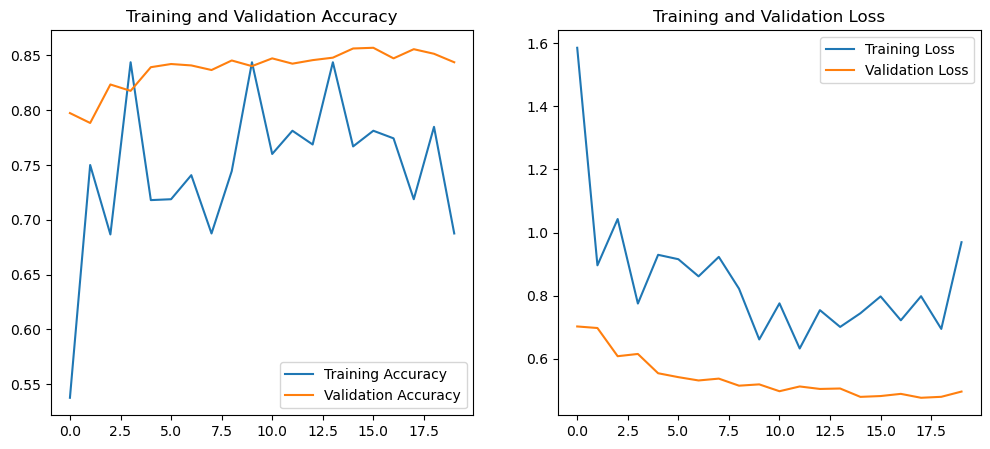

Final Validation Accuracy: 84.38%


In [9]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

print(f"Final Validation Accuracy: {val_acc[-1]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


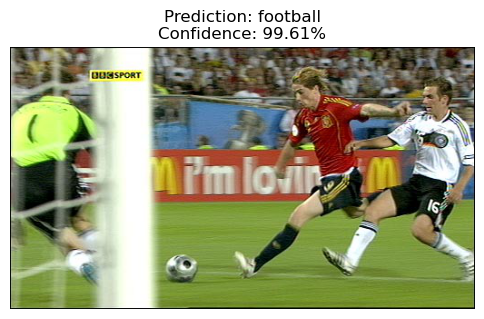

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# 1. Load the trained model
model = load_model(r'D:\Study\6th Semester\Labs\ANN LAB\my_sports_classifier.h5')


try:
    labels = {v: k for k, v in train_generator.class_indices.items()}
except NameError:
    # Fallback: Manually list your folders in alphabetical order if generator is gone
    print("Note: train_generator not found. Using folder indices.")
    labels = None

def predict_and_show(img_path):
   
    img_display = image.load_img(img_path) 
    
    # Load and preprocess for the model
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Normalize

  
    predictions = model.predict(img_array)
    class_idx = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100
    
    result_text = labels[class_idx] if labels else f"Class {class_idx}"

    plt.figure(figsize=(6, 6))
    plt.imshow(img_display)
    plt.title(f"Prediction: {result_text}\nConfidence: {confidence:.2f}%")
    plt.axis('off') # Hide the X and Y axis numbers
    plt.show()


test_image_path = r"D:\Study\6th Semester\Labs\ANN LAB\6.jpg"
predict_and_show(test_image_path)